# Playlist Analysis - Calm vs Upbeat

---

This notebook analyzes the audio features of personalized playlists to verify proper separation between **Calm** (stress reduction) and **Upbeat** (energy boost) playlists.

In [2]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Playlists

In [3]:
# CONFIGURATION - Change these for different participants
participant_id = "TEST-001"
calm_file = "TEST-001_calm_playlist.csv"
upbeat_file = "TEST-001_upbeat_playlist.csv"

# Load data
df_calm = pd.read_csv(calm_file)
df_upbeat = pd.read_csv(upbeat_file)

# Add playlist type label
df_calm['playlist_type'] = 'Calm'
df_upbeat['playlist_type'] = 'Upbeat'

# Combine for comparison
df_combined = pd.concat([df_calm, df_upbeat], ignore_index=True)

print(f"✓ Loaded playlists for {participant_id}")
print(f"  - Calm: {len(df_calm)} songs")
print(f"  - Upbeat: {len(df_upbeat)} songs")
print(f"  - Total: {len(df_combined)} songs")

✓ Loaded playlists for TEST-001
  - Calm: 12 songs
  - Upbeat: 12 songs
  - Total: 24 songs


## 2. Playlist Overview

In [4]:
# Display columns
display_cols = ['name', 'artists', 'tempo', 'energy', 'valence', 'acousticness', 'danceability']

print("="*80)
print("CALM PLAYLIST (Stress Reduction)")
print("="*80)
print(df_calm[display_cols].to_string(index=False))

print(f"\nTotal duration: {df_calm['duration_ms'].sum() / 60000:.1f} minutes")

print("\n" + "="*80)
print("UPBEAT PLAYLIST (Energy Boost)")
print("="*80)
print(df_upbeat[display_cols].to_string(index=False))

print(f"\nTotal duration: {df_upbeat['duration_ms'].sum() / 60000:.1f} minutes")

CALM PLAYLIST (Stress Reduction)
                        name             artists   tempo  energy  valence  acousticness  danceability
                 Gorik Pt. 2        Zwangere Guy  95.097   0.498    0.333         0.897         0.686
  Als Ik Voor Jou Kon Kiezen              MAKSIM 108.063   0.609    0.641         0.652         0.665
Ik moet dringend op vakantie          Yong Yello  98.989   0.751    0.586         0.486         0.724
                   Grenadine               Jokke  89.951   0.638    0.461         0.477         0.670
              Mauvais Garçon              Helena  96.937   0.414    0.679         0.434         0.710
               Crazy For You               Milow 100.031   0.557    0.811         0.425         0.847
  hi, how's your girlfriend?              Judith  77.510   0.459    0.516         0.393         0.481
                Sterrenwacht Tourist LeMC;Guusje  95.025   0.596    0.498         0.373         0.736
                     Papucho        Zwangere Guy 

## 3. Summary Statistics

In [5]:
# Key audio features to analyze
audio_features = ['tempo', 'energy', 'valence', 'acousticness', 'danceability', 'Loudness', 'Speechiness']

# Calculate statistics
def calc_stats(df, playlist_name):
    stats = {}
    for feature in audio_features:
        if feature in df.columns:
            stats[feature] = {
                'Mean': df[feature].mean(),
                'Std': df[feature].std(),
                'Min': df[feature].min(),
                'Max': df[feature].max(),
                'Median': df[feature].median()
            }
    return pd.DataFrame(stats).T

# Calculate for both playlists
stats_calm = calc_stats(df_calm, 'Calm')
stats_upbeat = calc_stats(df_upbeat, 'Upbeat')

print("="*80)
print("CALM PLAYLIST - Statistics")
print("="*80)
print(stats_calm.round(2))

print("\n" + "="*80)
print("UPBEAT PLAYLIST - Statistics")
print("="*80)
print(stats_upbeat.round(2))

CALM PLAYLIST - Statistics
               Mean    Std    Min     Max  Median
tempo         93.29  12.23  72.89  109.99   96.02
energy         0.55   0.12   0.33    0.75    0.57
valence        0.52   0.19   0.27    0.81    0.51
acousticness   0.45   0.17   0.28    0.90    0.41
danceability   0.70   0.09   0.48    0.85    0.70
Loudness      -7.95   1.98 -12.01   -4.52   -7.87
Speechiness    0.13   0.11   0.03    0.32    0.07

UPBEAT PLAYLIST - Statistics
                Mean   Std     Min     Max  Median
tempo         123.23  4.19  116.99  129.94  122.98
energy          0.79  0.08    0.61    0.90    0.80
valence         0.64  0.13    0.47    0.93    0.62
acousticness    0.10  0.12    0.00    0.38    0.05
danceability    0.69  0.07    0.59    0.80    0.69
Loudness       -5.86  1.61   -9.27   -2.39   -5.71
Speechiness     0.06  0.03    0.03    0.16    0.05


## 4. Feature Comparison Table

In [6]:
# Create comparison table
comparison = pd.DataFrame({
    'Feature': audio_features,
    'Calm (Mean)': [df_calm[f].mean() if f in df_calm.columns else np.nan for f in audio_features],
    'Upbeat (Mean)': [df_upbeat[f].mean() if f in df_upbeat.columns else np.nan for f in audio_features],
    'Difference': [df_upbeat[f].mean() - df_calm[f].mean() if f in df_calm.columns else np.nan for f in audio_features],
    '% Change': [(df_upbeat[f].mean() - df_calm[f].mean()) / df_calm[f].mean() * 100 if f in df_calm.columns and df_calm[f].mean() != 0 else np.nan for f in audio_features]
})

print("="*80)
print("FEATURE COMPARISON - Calm vs Upbeat")
print("="*80)
print(comparison.round(2).to_string(index=False))

# Highlight key differences
print("\n" + "="*80)
print("KEY DIFFERENCES")
print("="*80)

for idx, row in comparison.iterrows():
    feature = row['Feature']
    diff = row['Difference']
    pct = row['% Change']
    
    if abs(pct) > 20:  # Significant difference
        direction = "higher" if diff > 0 else "lower"
        print(f"  - {feature}: Upbeat is {abs(pct):.1f}% {direction} ({diff:+.2f})")

FEATURE COMPARISON - Calm vs Upbeat
     Feature  Calm (Mean)  Upbeat (Mean)  Difference  % Change
       tempo        93.29         123.23       29.94     32.09
      energy         0.55           0.79        0.24     44.56
     valence         0.52           0.64        0.12     23.75
acousticness         0.45           0.10       -0.35    -77.95
danceability         0.70           0.69       -0.01     -1.33
    Loudness        -7.95          -5.86        2.09    -26.26
 Speechiness         0.13           0.06       -0.07    -55.47

KEY DIFFERENCES
  - tempo: Upbeat is 32.1% higher (+29.94)
  - energy: Upbeat is 44.6% higher (+0.24)
  - valence: Upbeat is 23.8% higher (+0.12)
  - acousticness: Upbeat is 77.9% lower (-0.35)
  - Loudness: Upbeat is 26.3% higher (+2.09)
  - Speechiness: Upbeat is 55.5% lower (-0.07)


## 5. Visualizations

### 5.1 Box Plot Comparison

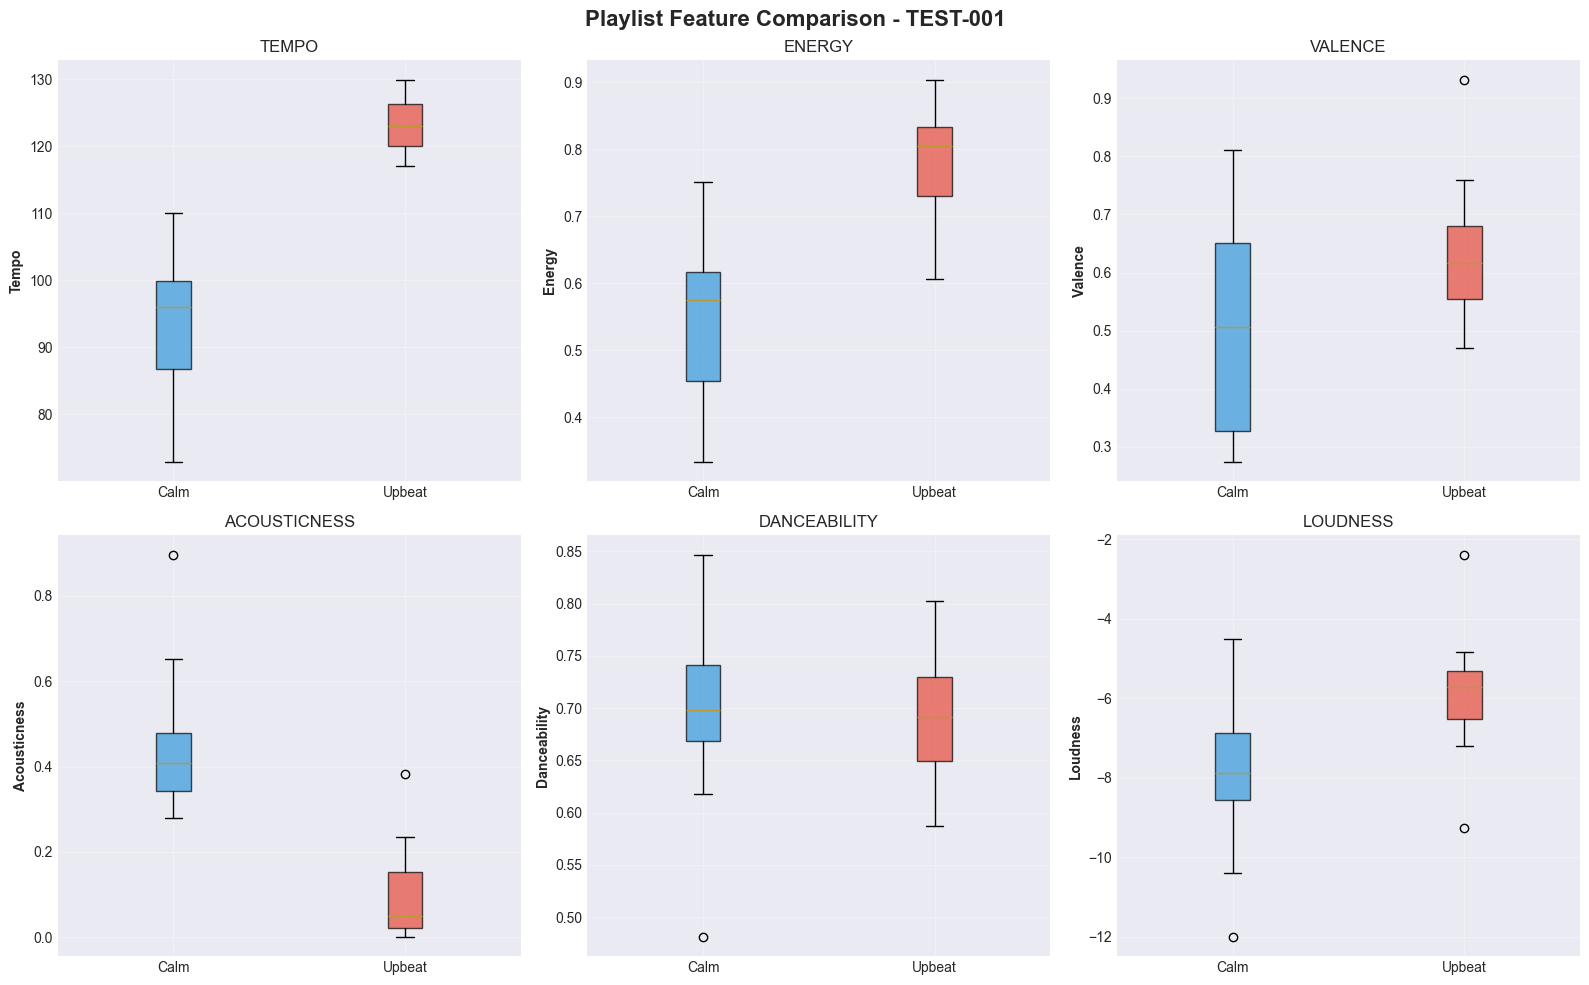

✓ Saved: TEST-001_feature_comparison_boxplots.png


In [7]:
# Box plots for key features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'Playlist Feature Comparison - {participant_id}', fontsize=16, fontweight='bold')

features_to_plot = ['tempo', 'energy', 'valence', 'acousticness', 'danceability', 'Loudness']
colors = ['#3498db', '#e74c3c']  # Blue for Calm, Red for Upbeat

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    if feature in df_combined.columns:
        data = [df_calm[feature].dropna(), df_upbeat[feature].dropna()]
        bp = ax.boxplot(data, labels=['Calm', 'Upbeat'], patch_artist=True)
        
        # Color the boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_ylabel(feature.capitalize(), fontweight='bold')
        ax.set_title(feature.upper())
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{feature}\nNot Available', ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig(f'{participant_id}_feature_comparison_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {participant_id}_feature_comparison_boxplots.png")

### 5.2 Radar Chart (Spider Plot)

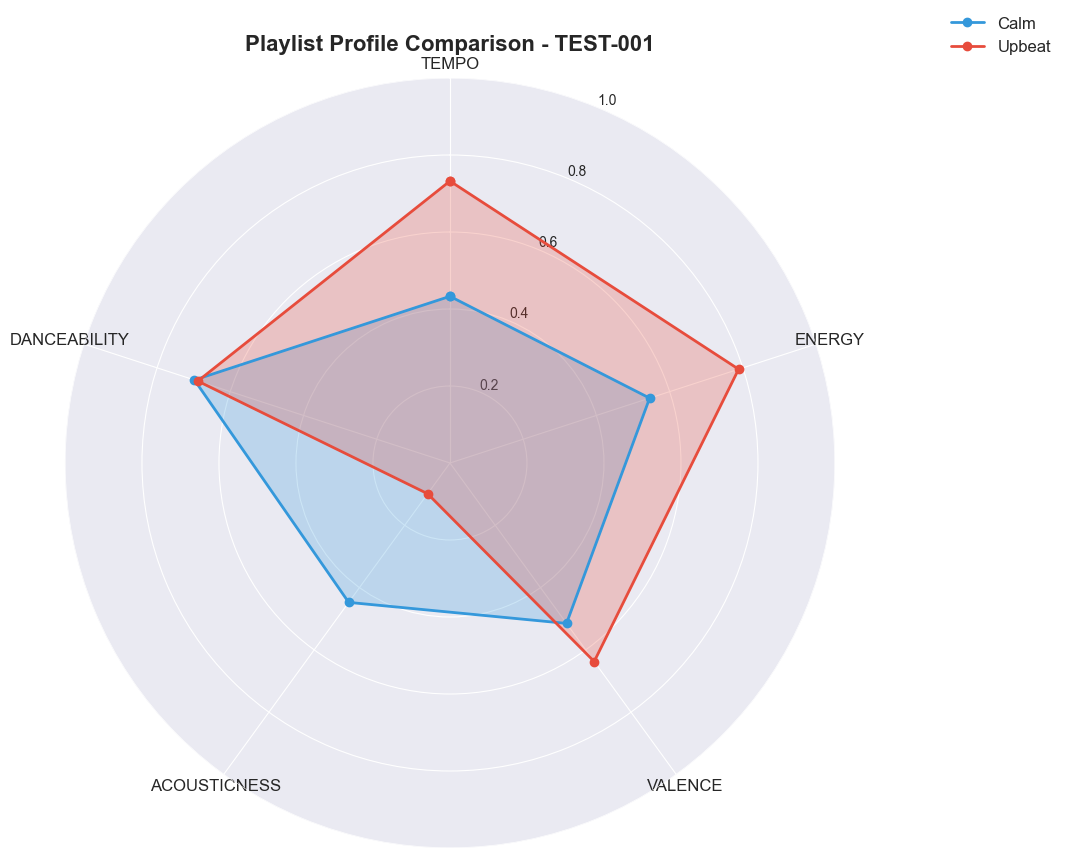

✓ Saved: TEST-001_radar_chart.png


In [8]:
# Radar chart comparing playlist profiles
from math import pi

# Normalize features to 0-1 scale for radar chart
features_radar = ['tempo', 'energy', 'valence', 'acousticness', 'danceability']

# Get normalized means
calm_values = []
upbeat_values = []

for feature in features_radar:
    if feature in df_combined.columns:
        # Normalize tempo (typically 50-150) to 0-1
        if feature == 'tempo':
            calm_val = (df_calm[feature].mean() - 50) / 100
            upbeat_val = (df_upbeat[feature].mean() - 50) / 100
        else:
            # Other features already 0-1
            calm_val = df_calm[feature].mean()
            upbeat_val = df_upbeat[feature].mean()
        
        calm_values.append(calm_val)
        upbeat_values.append(upbeat_val)

# Number of variables
num_vars = len(features_radar)

# Compute angle for each axis
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
calm_values += calm_values[:1]  # Complete the circle
upbeat_values += upbeat_values[:1]
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Plot data
ax.plot(angles, calm_values, 'o-', linewidth=2, label='Calm', color='#3498db')
ax.fill(angles, calm_values, alpha=0.25, color='#3498db')

ax.plot(angles, upbeat_values, 'o-', linewidth=2, label='Upbeat', color='#e74c3c')
ax.fill(angles, upbeat_values, alpha=0.25, color='#e74c3c')

# Fix axis to go in the right order and start at 12 o'clock
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.upper() for f in features_radar], size=12)

# Set y-axis limits
ax.set_ylim(0, 1)

# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
plt.title(f'Playlist Profile Comparison - {participant_id}', size=16, fontweight='bold', pad=20)

plt.savefig(f'{participant_id}_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {participant_id}_radar_chart.png")

### 5.3 Distribution Histograms

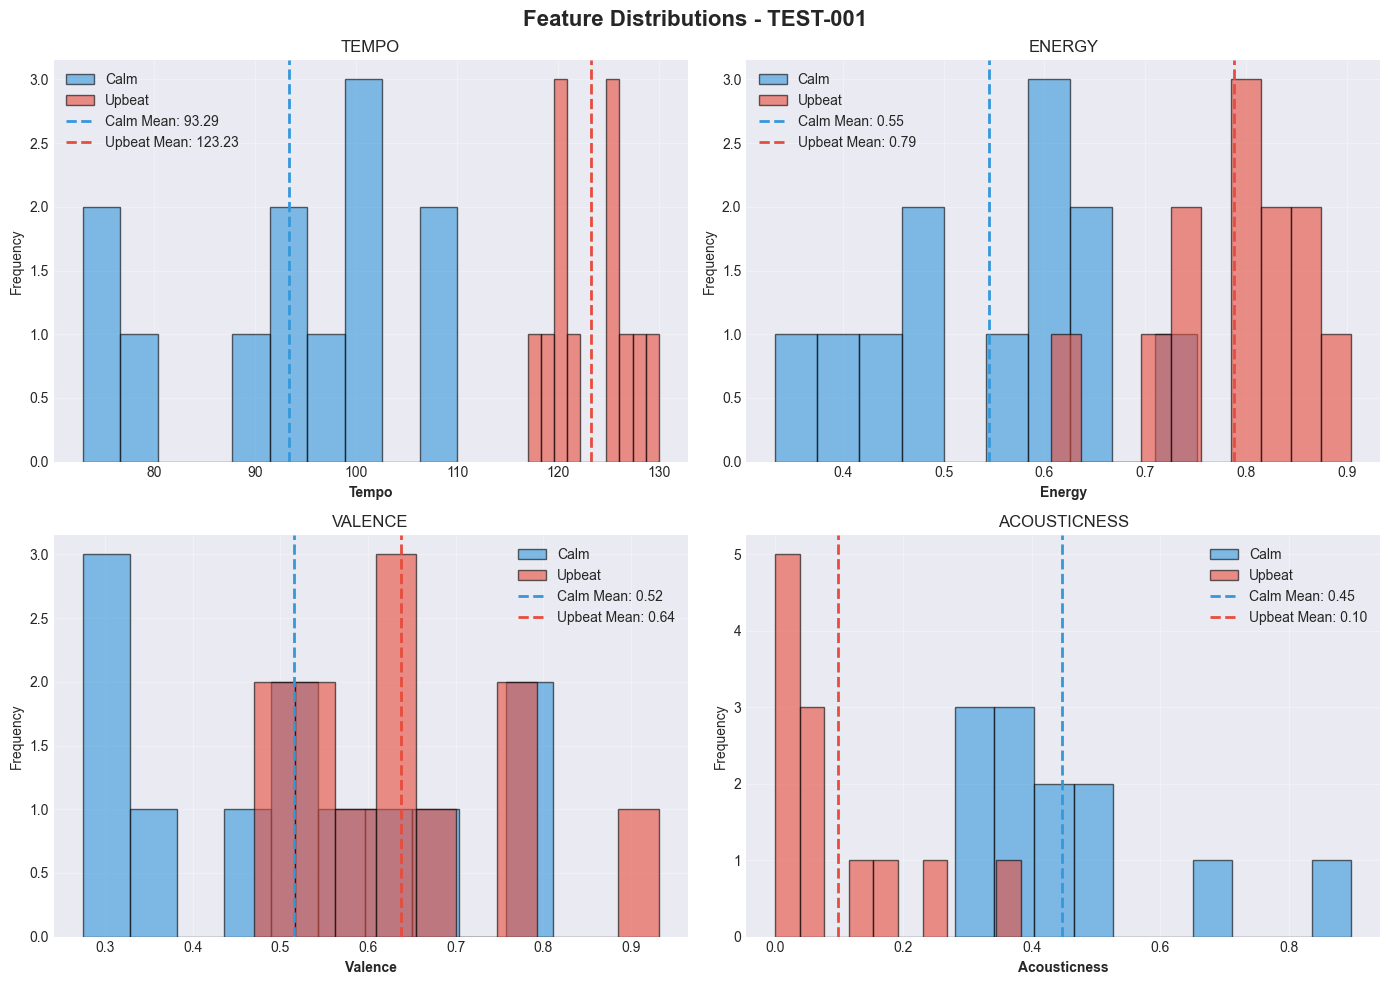

✓ Saved: TEST-001_distributions.png


In [9]:
# Distribution histograms for key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Feature Distributions - {participant_id}', fontsize=16, fontweight='bold')

features_dist = ['tempo', 'energy', 'valence', 'acousticness']

for idx, feature in enumerate(features_dist):
    ax = axes[idx // 2, idx % 2]
    
    if feature in df_combined.columns:
        # Plot histograms
        ax.hist(df_calm[feature].dropna(), bins=10, alpha=0.6, label='Calm', color='#3498db', edgecolor='black')
        ax.hist(df_upbeat[feature].dropna(), bins=10, alpha=0.6, label='Upbeat', color='#e74c3c', edgecolor='black')
        
        # Add mean lines
        ax.axvline(df_calm[feature].mean(), color='#3498db', linestyle='--', linewidth=2, label=f'Calm Mean: {df_calm[feature].mean():.2f}')
        ax.axvline(df_upbeat[feature].mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Upbeat Mean: {df_upbeat[feature].mean():.2f}')
        
        ax.set_xlabel(feature.capitalize(), fontweight='bold')
        ax.set_ylabel('Frequency')
        ax.set_title(feature.upper())
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{participant_id}_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {participant_id}_distributions.png")

### 5.4 Scatter Plots - Tempo vs Energy

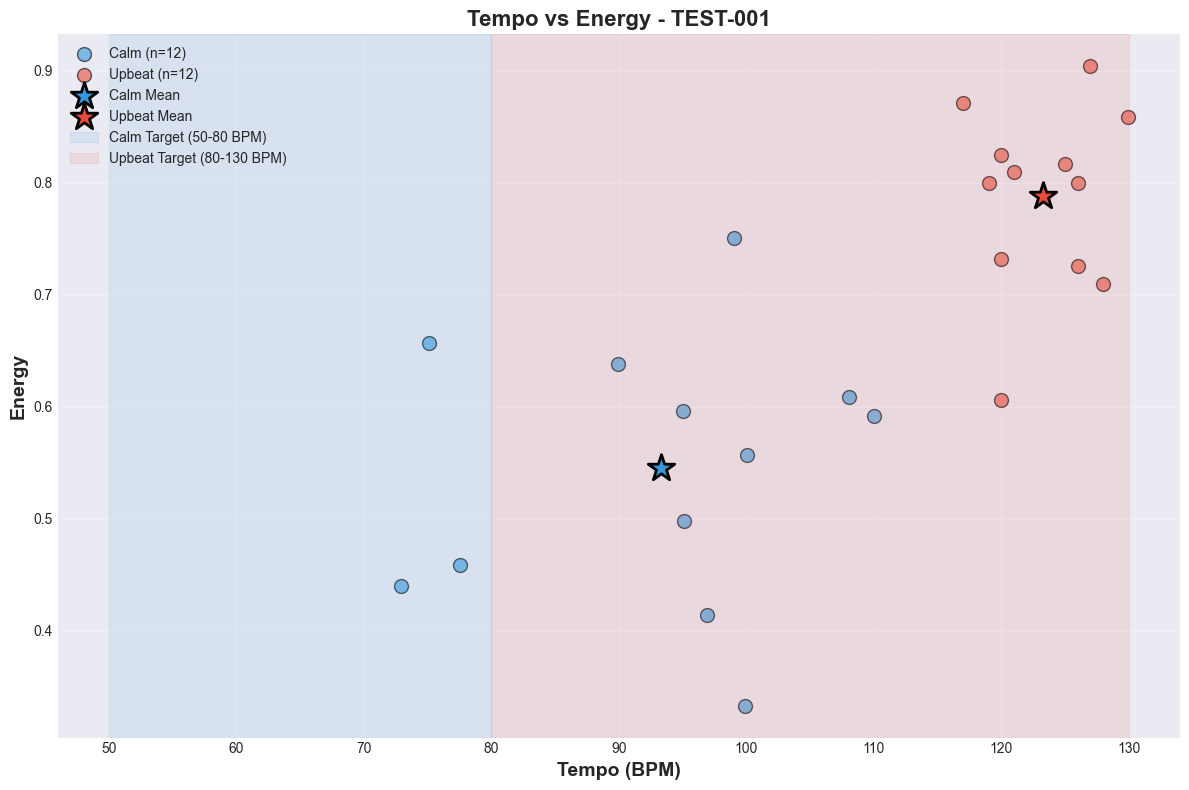

✓ Saved: TEST-001_tempo_vs_energy.png


In [10]:
# Scatter plot: Tempo vs Energy
fig, ax = plt.subplots(figsize=(12, 8))

# Plot calm songs
ax.scatter(df_calm['tempo'], df_calm['energy'], 
           s=100, alpha=0.6, c='#3498db', edgecolors='black', linewidth=1,
           label=f'Calm (n={len(df_calm)})')

# Plot upbeat songs
ax.scatter(df_upbeat['tempo'], df_upbeat['energy'], 
           s=100, alpha=0.6, c='#e74c3c', edgecolors='black', linewidth=1,
           label=f'Upbeat (n={len(df_upbeat)})')

# Add mean markers
ax.scatter(df_calm['tempo'].mean(), df_calm['energy'].mean(),
           s=400, marker='*', c='#3498db', edgecolors='black', linewidth=2,
           label='Calm Mean', zorder=5)

ax.scatter(df_upbeat['tempo'].mean(), df_upbeat['energy'].mean(),
           s=400, marker='*', c='#e74c3c', edgecolors='black', linewidth=2,
           label='Upbeat Mean', zorder=5)

# Add target zones
ax.axvspan(50, 80, alpha=0.1, color='#3498db', label='Calm Target (50-80 BPM)')
ax.axvspan(80, 130, alpha=0.1, color='#e74c3c', label='Upbeat Target (80-130 BPM)')

ax.set_xlabel('Tempo (BPM)', fontsize=14, fontweight='bold')
ax.set_ylabel('Energy', fontsize=14, fontweight='bold')
ax.set_title(f'Tempo vs Energy - {participant_id}', fontsize=16, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{participant_id}_tempo_vs_energy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {participant_id}_tempo_vs_energy.png")

### 5.5 Valence vs Energy (Mood Quadrant)

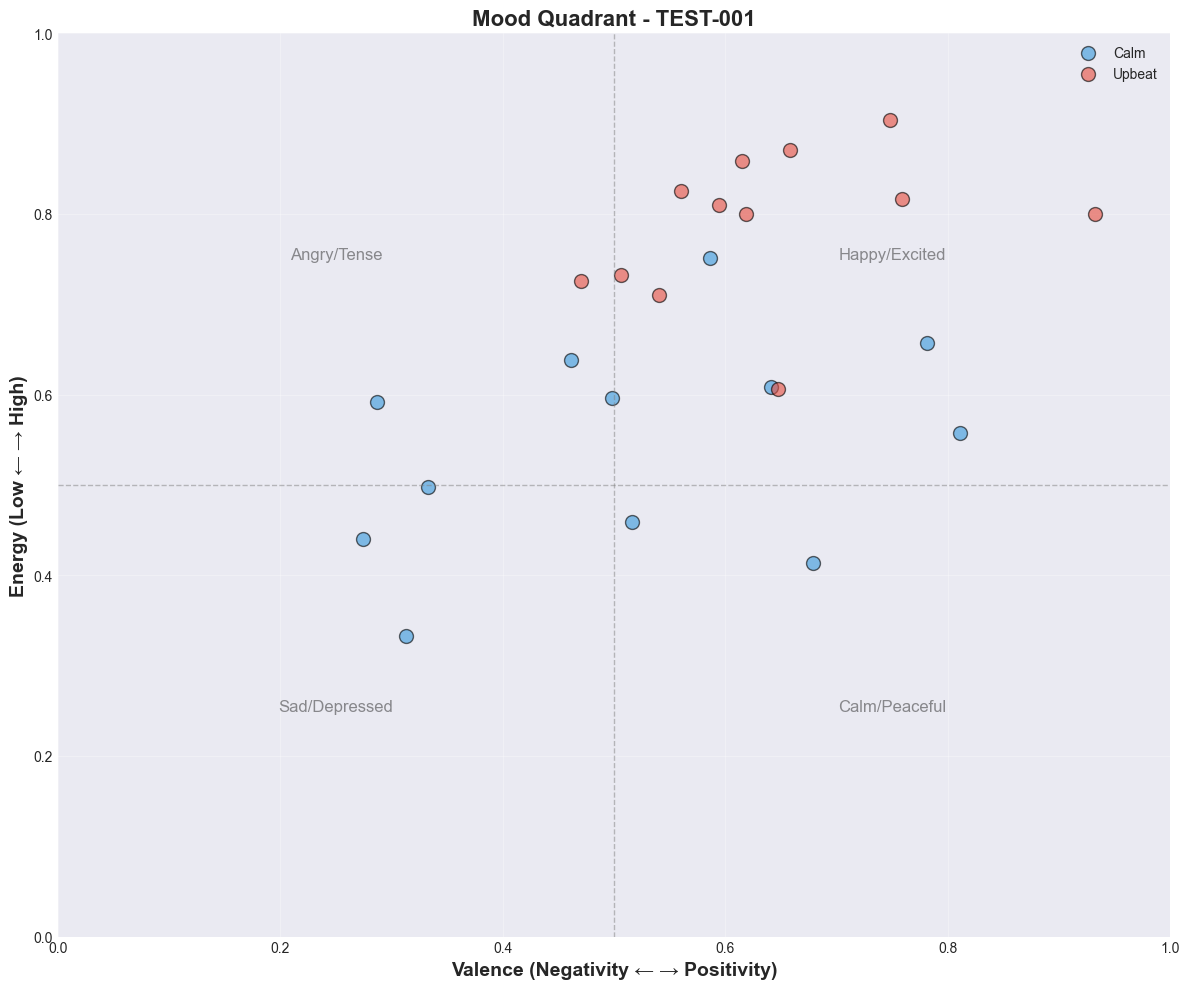

✓ Saved: TEST-001_mood_quadrant.png


In [11]:
# Mood quadrant: Valence (positivity) vs Energy (arousal)
fig, ax = plt.subplots(figsize=(12, 10))

# Plot songs
ax.scatter(df_calm['valence'], df_calm['energy'], 
           s=100, alpha=0.6, c='#3498db', edgecolors='black', linewidth=1,
           label='Calm')

ax.scatter(df_upbeat['valence'], df_upbeat['energy'], 
           s=100, alpha=0.6, c='#e74c3c', edgecolors='black', linewidth=1,
           label='Upbeat')

# Add quadrant lines
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add quadrant labels
ax.text(0.75, 0.75, 'Happy/Excited', fontsize=12, ha='center', alpha=0.5)
ax.text(0.25, 0.75, 'Angry/Tense', fontsize=12, ha='center', alpha=0.5)
ax.text(0.25, 0.25, 'Sad/Depressed', fontsize=12, ha='center', alpha=0.5)
ax.text(0.75, 0.25, 'Calm/Peaceful', fontsize=12, ha='center', alpha=0.5)

ax.set_xlabel('Valence (Negativity ← → Positivity)', fontsize=14, fontweight='bold')
ax.set_ylabel('Energy (Low ← → High)', fontsize=14, fontweight='bold')
ax.set_title(f'Mood Quadrant - {participant_id}', fontsize=16, fontweight='bold')
ax.legend(loc='best')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{participant_id}_mood_quadrant.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {participant_id}_mood_quadrant.png")

## 6. Validation Checks

In [12]:
print("="*80)
print("VALIDATION CHECKS")
print("="*80)

# Check 1: Tempo separation
calm_tempo_mean = df_calm['tempo'].mean()
upbeat_tempo_mean = df_upbeat['tempo'].mean()

print("\n1. TEMPO SEPARATION")
print(f"   Calm mean: {calm_tempo_mean:.1f} BPM (target: 50-80)")
print(f"   Upbeat mean: {upbeat_tempo_mean:.1f} BPM (target: 80-130)")
print(f"   Difference: {upbeat_tempo_mean - calm_tempo_mean:.1f} BPM")

if 50 <= calm_tempo_mean <= 80 and 80 <= upbeat_tempo_mean <= 130:
    print("   ✓ PASS: Both playlists within target ranges")
else:
    print("   ⚠ WARNING: One or both playlists outside target range")

# Check 2: Energy separation
calm_energy_mean = df_calm['energy'].mean()
upbeat_energy_mean = df_upbeat['energy'].mean()

print("\n2. ENERGY SEPARATION")
print(f"   Calm mean: {calm_energy_mean:.2f} (target: <0.5)")
print(f"   Upbeat mean: {upbeat_energy_mean:.2f} (target: >0.6)")
print(f"   Difference: {upbeat_energy_mean - calm_energy_mean:.2f}")

if calm_energy_mean < 0.5 and upbeat_energy_mean > 0.6:
    print("   ✓ PASS: Clear energy separation")
else:
    print("   ⚠ WARNING: Energy levels might overlap")

# Check 3: Statistical significance (t-test)
from scipy import stats

print("\n3. STATISTICAL SIGNIFICANCE (t-tests)")

for feature in ['tempo', 'energy', 'valence']:
    if feature in df_combined.columns:
        t_stat, p_value = stats.ttest_ind(df_calm[feature].dropna(), df_upbeat[feature].dropna())
        
        print(f"   {feature.capitalize()}:")
        print(f"     t-statistic: {t_stat:.3f}")
        print(f"     p-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print("     ✓ SIGNIFICANT: Playlists are significantly different (p < 0.05)")
        else:
            print("     ⚠ NOT SIGNIFICANT: Difference might be due to chance (p >= 0.05)")

# Check 4: Duration
calm_duration = df_calm['duration_ms'].sum() / 60000
upbeat_duration = df_upbeat['duration_ms'].sum() / 60000

print("\n4. PLAYLIST DURATION")
print(f"   Calm: {calm_duration:.1f} minutes")
print(f"   Upbeat: {upbeat_duration:.1f} minutes")
print("   Target: ~30 minutes each")

if calm_duration >= 25 and upbeat_duration >= 25:
    print("   ✓ PASS: Both playlists meet minimum duration")
else:
    print("   ⚠ WARNING: One or both playlists too short")

# Overall assessment
print("\n" + "="*80)
print("OVERALL ASSESSMENT")
print("="*80)

checks_passed = 0
total_checks = 4

if 50 <= calm_tempo_mean <= 80 and 80 <= upbeat_tempo_mean <= 130:
    checks_passed += 1

if calm_energy_mean < 0.5 and upbeat_energy_mean > 0.6:
    checks_passed += 1

t_stat, p_value = stats.ttest_ind(df_calm['tempo'].dropna(), df_upbeat['tempo'].dropna())
if p_value < 0.05:
    checks_passed += 1

if calm_duration >= 25 and upbeat_duration >= 25:
    checks_passed += 1

print(f"Checks passed: {checks_passed}/{total_checks}")

if checks_passed == total_checks:
    print("\n✓ EXCELLENT: Playlists are well-separated and ready for study")
elif checks_passed >= 3:
    print("\n✓ GOOD: Playlists show clear differences, usable for study")
elif checks_passed >= 2:
    print("\n⚠ ACCEPTABLE: Some differences present, but consider reviewing")
else:
    print("\n✗ NEEDS IMPROVEMENT: Playlists may be too similar")

VALIDATION CHECKS

1. TEMPO SEPARATION
   Calm mean: 93.3 BPM (target: 50-80)
   Upbeat mean: 123.2 BPM (target: 80-130)
   Difference: 29.9 BPM
   ⚠ WARNING: One or both playlists outside target range

2. ENERGY SEPARATION
   Calm mean: 0.55 (target: <0.5)
   Upbeat mean: 0.79 (target: >0.6)
   Difference: 0.24
   ⚠ WARNING: Energy levels might overlap

3. STATISTICAL SIGNIFICANCE (t-tests)
   Tempo:
     t-statistic: -8.022
     p-value: 0.0000
     ✓ SIGNIFICANT: Playlists are significantly different (p < 0.05)
   Energy:
     t-statistic: -5.822
     p-value: 0.0000
     ✓ SIGNIFICANT: Playlists are significantly different (p < 0.05)
   Valence:
     t-statistic: -1.860
     p-value: 0.0764
     ⚠ NOT SIGNIFICANT: Difference might be due to chance (p >= 0.05)

4. PLAYLIST DURATION
   Calm: 35.2 minutes
   Upbeat: 37.1 minutes
   Target: ~30 minutes each
   ✓ PASS: Both playlists meet minimum duration

OVERALL ASSESSMENT
Checks passed: 2/4

⚠ ACCEPTABLE: Some differences present, bu

## 7. Export Summary Report

In [13]:
# Create summary report
report = f"""
PLAYLIST ANALYSIS REPORT
========================
Participant: {participant_id}
Date: {datetime.today().strftime('%Y-%m-%d')}

PLAYLIST SIZES
--------------
Calm: {len(df_calm)} songs ({calm_duration:.1f} minutes)
Upbeat: {len(df_upbeat)} songs ({upbeat_duration:.1f} minutes)

KEY METRICS (Mean Values)
--------------------------
                  Calm      Upbeat    Difference
Tempo (BPM)       {calm_tempo_mean:.1f}      {upbeat_tempo_mean:.1f}       {upbeat_tempo_mean - calm_tempo_mean:+.1f}
Energy            {calm_energy_mean:.2f}       {upbeat_energy_mean:.2f}       {upbeat_energy_mean - calm_energy_mean:+.2f}
Valence           {df_calm['valence'].mean():.2f}       {df_upbeat['valence'].mean():.2f}       {df_upbeat['valence'].mean() - df_calm['valence'].mean():+.2f}
Acousticness      {df_calm['acousticness'].mean():.2f}       {df_upbeat['acousticness'].mean():.2f}       {df_upbeat['acousticness'].mean() - df_calm['acousticness'].mean():+.2f}
Danceability      {df_calm['danceability'].mean():.2f}       {df_upbeat['danceability'].mean():.2f}       {df_upbeat['danceability'].mean() - df_calm['danceability'].mean():+.2f}

VALIDATION STATUS
-----------------
Checks passed: {checks_passed}/{total_checks}

CONCLUSION
----------
"""

if checks_passed >= 3:
    report += "Playlists show clear separation and are suitable for the study.\n"
else:
    report += "Playlists may need adjustment for clearer separation.\n"

# Save report
with open(f'{participant_id}_analysis_report.txt', 'w') as f:
    f.write(report)

print(report)
print(f"\n✓ Report saved: {participant_id}_analysis_report.txt")


PLAYLIST ANALYSIS REPORT
Participant: TEST-001
Date: 2026-01-03

PLAYLIST SIZES
--------------
Calm: 12 songs (35.2 minutes)
Upbeat: 12 songs (37.1 minutes)

KEY METRICS (Mean Values)
--------------------------
                  Calm      Upbeat    Difference
Tempo (BPM)       93.3      123.2       +29.9
Energy            0.55       0.79       +0.24
Valence           0.52       0.64       +0.12
Acousticness      0.45       0.10       -0.35
Danceability      0.70       0.69       -0.01

VALIDATION STATUS
-----------------
Checks passed: 2/4

CONCLUSION
----------
Playlists may need adjustment for clearer separation.


✓ Report saved: TEST-001_analysis_report.txt


## Summary

This analysis has:
1. ✓ Loaded and displayed both playlists
2. ✓ Calculated summary statistics
3. ✓ Created comparison visualizations
4. ✓ Validated playlist separation
5. ✓ Generated exportable report

**Generated files**:
- `{participant_id}_feature_comparison_boxplots.png`
- `{participant_id}_radar_chart.png`
- `{participant_id}_distributions.png`
- `{participant_id}_tempo_vs_energy.png`
- `{participant_id}_mood_quadrant.png`
- `{participant_id}_analysis_report.txt`